### Importação dos dados



In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# URLs das lojas
urls = {
    "Loja 1": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv",
    "Loja 2": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv",
    "Loja 3": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv",
    "Loja 4": "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"
}

dataframes = []
for nome_loja, url in urls.items():
    df = pd.read_csv(url)
    df['Loja'] = nome_loja
    dataframes.append(df)

df_completo = pd.concat(dataframes, ignore_index=True)

#1. Análise do faturamento



In [12]:
faturamento_por_loja = df_completo.groupby('Loja')['Preço'].sum()
print("Faturamento por Loja:")
print(faturamento_por_loja)



Faturamento por Loja:
Loja
Loja 1    1534509.12
Loja 2    1488459.06
Loja 3    1464025.03
Loja 4    1384497.58
Name: Preço, dtype: float64


In [13]:
analise_lojas = df_completo.groupby('Loja').agg({
    'Preço': ['sum', 'mean', 'count', 'max'],
    'Frete': 'sum',
    'Avaliação da compra': 'mean'
}).round(2)


In [14]:
analise_lojas.columns = ['Faturamento_Total', 'Ticket_Medio', 'Qtd_Vendas', 'Maior_Venda', 'Frete_Total', 'Avaliação_Media']
print("\nAnálise Completa por Loja:")
analise_lojas.head()


Análise Completa por Loja:


,Faturamento_Total,Ticket_Medio,Qtd_Vendas,Maior_Venda,Frete_Total,Avaliação_Media
Loja,,,,,,
Loja 1,1534509.12,650.49,2359,3969.38,81837.97,3.98
Loja 2,1488459.06,630.97,2359,3937.85,79314.16,4.04
Loja 3,1464025.03,620.61,2359,3957.62,78022.66,4.05
Loja 4,1384497.58,587.15,2358,3869.56,73755.88,4.00


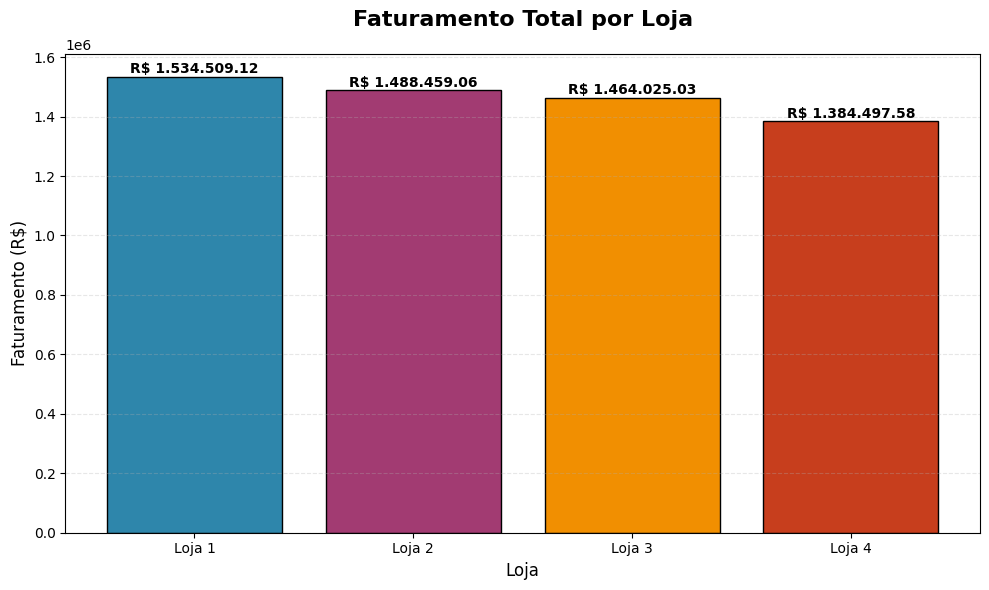

In [15]:
faturamento = df_completo.groupby('Loja')['Preço'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = plt.bar(faturamento.index, faturamento.values, color=colors, edgecolor='black', linewidth=1)

plt.title('Faturamento Total por Loja', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, valor in zip(bars, faturamento.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'R$ {valor:,.2f}'.replace(',', '.'),
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 2. Vendas por Categoria

In [16]:
vendas_categoria = df_completo.groupby('Categoria do Produto').agg({
    'Preço': ['sum', 'mean', 'count', 'max'],
    'Frete': 'sum',
    'Avaliação da compra': 'mean'
}).round(2)

vendas_categoria.columns = ['Faturamento_Total', 'Ticket_Medio', 'Qtd_Vendas', 'Maior_Venda', 'Frete_Total', 'Avaliacao_Media']
vendas_categoria = vendas_categoria.reset_index()
vendas_categoria = vendas_categoria.sort_values('Faturamento_Total', ascending=False)

print(vendas_categoria.to_string(index=False))

 Categoria do Produto  Faturamento_Total  Ticket_Medio  Qtd_Vendas  Maior_Venda  Frete_Total  Avaliacao_Media
          eletronicos         2214099.72       1249.49        1772      3969.38    117948.36             3.99
     eletrodomesticos         1766337.03       1537.28        1149      3399.04     93861.63             4.01
               moveis         1010214.00        535.64        1886      1296.59     53935.77             4.03
instrumentos musicais          465029.67        617.57         753      1496.64     24671.81             4.00
      esporte e lazer          190635.39        171.28        1113       999.67     10256.55             3.99
           brinquedos           98140.86         76.08        1290       348.03      5361.50             4.07
utilidades domesticas           76773.38        105.17         730       296.91      4148.34             3.98
               livros           50260.74         67.74         742       109.33      2746.69             4.00


Análise por categoria em cada loja

In [17]:
vendas_categoria_loja = df_completo.groupby(['Loja', 'Categoria do Produto']).agg({
    'Preço': ['sum', 'mean', 'count'],
    'Avaliação da compra': 'mean'
}).round(2)

vendas_categoria_loja.columns = ['Faturamento', 'Ticket_Medio', 'Qtd_Vendas', 'Avaliacao_Media']
vendas_categoria_loja = vendas_categoria_loja.reset_index()

vendas_categoria_loja.head(20)

,Loja,Categoria do Produto,Faturamento,Ticket_Medio,Qtd_Vendas,Avaliacao_Media
0,Loja 1,brinquedos,23993.78,74.05,324,4.08
1,Loja 1,eletrodomesticos,484913.36,1554.21,312,4.03
2,Loja 1,eletronicos,572659.23,1278.26,448,4.00
3,Loja 1,esporte e lazer,52387.55,184.46,284,3.90
4,Loja 1,instrumentos musicais,121731.69,668.86,182,4.05
5,Loja 1,livros,11713.92,67.71,173,3.98
6,Loja 1,moveis,250178.11,538.02,465,3.95
7,Loja 1,utilidades domesticas,16931.48,99.01,171,3.75
8,Loja 2,brinquedos,21262.21,67.93,313,4.03
9,Loja 2,eletrodomesticos,464758.13,1523.80,305,4.07


Gráfico de faturamento por categoria

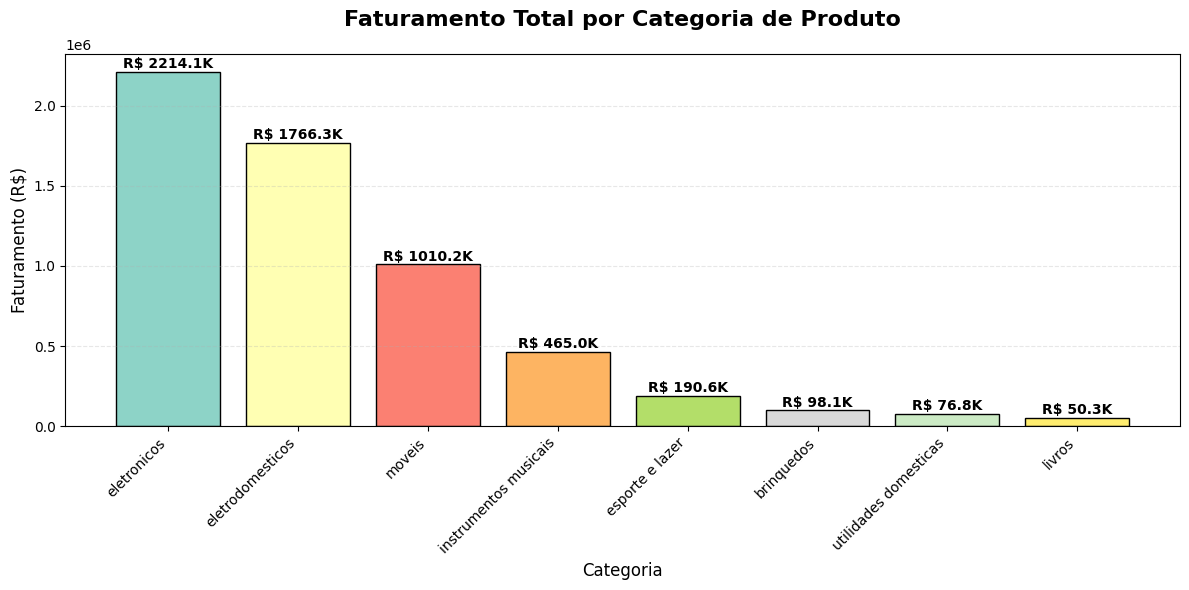

In [18]:
plt.figure(figsize=(12, 6))

categorias = vendas_categoria['Categoria do Produto']
valores = vendas_categoria['Faturamento_Total']

cores = plt.cm.Set3(np.linspace(0, 1, len(categorias)))

bars = plt.bar(categorias, valores, color=cores, edgecolor='black', linewidth=1)

plt.title('Faturamento Total por Categoria de Produto', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, valor in zip(bars, valores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'R$ {valor/1000:.1f}K', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Gráfico comparativo por loja e categoria

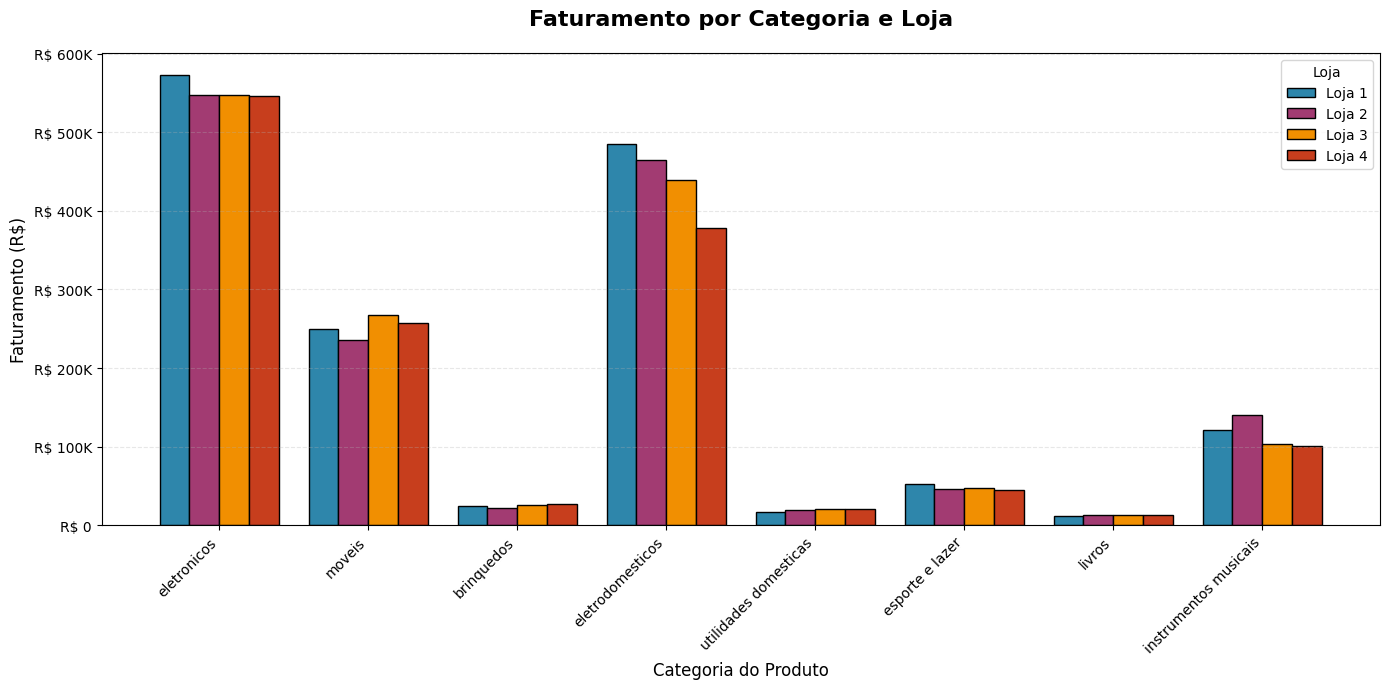

In [97]:
categorias_unicas = df_completo['Categoria do Produto'].unique()
lojas_unicas = df_completo['Loja'].unique()

dados_matriz = []
for categoria in categorias_unicas:
    linha = []
    for loja in lojas_unicas:
        valor = df_completo[(df_completo['Loja'] == loja) & 
                           (df_completo['Categoria do Produto'] == categoria)]['Preço'].sum()
        linha.append(valor)
    dados_matriz.append(linha)

x = np.arange(len(categorias_unicas))  
width = 0.2  

fig, ax = plt.subplots(figsize=(14, 7))

cores_lojas = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
for i, loja in enumerate(lojas_unicas):
    valores_loja = [dados_matriz[j][i] for j in range(len(categorias_unicas))]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, valores_loja, width, label=loja, 
                  color=cores_lojas[i], edgecolor='black', linewidth=1)
    
ax.set_xlabel('Categoria do Produto', fontsize=12)
ax.set_ylabel('Faturamento (R$)', fontsize=12)
ax.set_title('Faturamento por Categoria e Loja', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(categorias_unicas, rotation=45, ha='right')
ax.legend(title='Loja')
ax.grid(axis='y', alpha=0.3, linestyle='--')

def format_milhares(x, p):
    if x >= 1e6:
        return f'R$ {x/1e6:.1f}M'
    elif x >= 1e3:
        return f'R$ {x/1e3:.0f}K'
    else:
        return f'R$ {x:.0f}'

from matplotlib.ticker import FuncFormatter
ax.yaxis.set_major_formatter(FuncFormatter(format_milhares))

plt.tight_layout()
plt.show()

Ranking de categorias

In [94]:
vendas_categoria['Ranking_Faturamento'] = vendas_categoria['Faturamento_Total'].rank(ascending=False).astype(int)
print("\nRanking por Faturamento:")
for idx, row in vendas_categoria.sort_values('Ranking_Faturamento').iterrows():
    print(f"  {row['Ranking_Faturamento']}º - {row['Categoria do Produto']}: R$ {row['Faturamento_Total']:,.2f}")

vendas_categoria['Ranking_Qtd'] = vendas_categoria['Qtd_Vendas'].rank(ascending=False).astype(int)
print("\nRanking por Quantidade de Vendas:")
for idx, row in vendas_categoria.sort_values('Ranking_Qtd').iterrows():
    print(f"  {row['Ranking_Qtd']}º - {row['Categoria do Produto']}: {row['Qtd_Vendas']} vendas")

vendas_categoria['Ranking_Avaliacao'] = vendas_categoria['Avaliacao_Media'].rank(ascending=False).astype(int)
print("\nRanking por Avliação Média:")
for idx, row in vendas_categoria.sort_values('Ranking_Avaliacao').iterrows():
    print(f"  {row['Ranking_Avaliacao']}º - {row['Categoria do Produto']}: {row['Avaliacao_Media']:.2f}")


Ranking por Faturamento:
  1º - eletronicos: R$ 2,214,099.72
  2º - eletrodomesticos: R$ 1,766,337.03
  3º - moveis: R$ 1,010,214.00
  4º - instrumentos musicais: R$ 465,029.67
  5º - esporte e lazer: R$ 190,635.39
  6º - brinquedos: R$ 98,140.86
  7º - utilidades domesticas: R$ 76,773.38
  8º - livros: R$ 50,260.74

Ranking por Quantidade de Vendas:
  1º - moveis: 1886 vendas
  2º - eletronicos: 1772 vendas
  3º - brinquedos: 1290 vendas
  4º - eletrodomesticos: 1149 vendas
  5º - esporte e lazer: 1113 vendas
  6º - instrumentos musicais: 753 vendas
  7º - livros: 742 vendas
  8º - utilidades domesticas: 730 vendas

Ranking por Avliação Média:
  1º - brinquedos: 4.07
  2º - moveis: 4.03
  3º - eletrodomesticos: 4.01
  4º - instrumentos musicais: 4.00
  4º - livros: 4.00
  6º - eletronicos: 3.99
  6º - esporte e lazer: 3.99
  8º - utilidades domesticas: 3.98


# 3. Média de Avaliação das Lojas


In [93]:
media_avaliacao = df_completo.groupby('Loja')['Avaliação da compra'].mean().round(2)

media_avaliacao_df = media_avaliacao.reset_index()
media_avaliacao_df.columns = ['Loja', 'Média de Avaliação']
print(media_avaliacao_df.to_string(index=False))

  Loja  Média de Avaliação
Loja 1                3.98
Loja 2                4.04
Loja 3                4.05
Loja 4                4.00


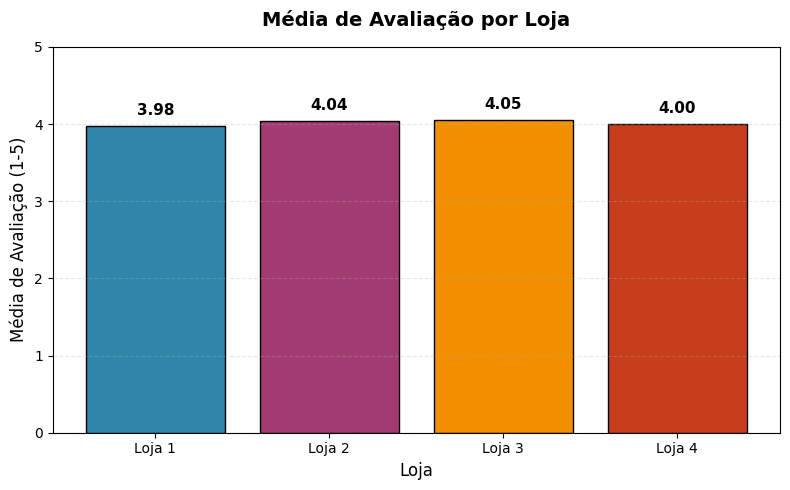

In [28]:

plt.figure(figsize=(8, 5))

cores = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bars = plt.bar(media_avaliacao.index, media_avaliacao.values, color=cores, edgecolor='black', linewidth=1)

plt.title('Média de Avaliação por Loja', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Loja', fontsize=12)
plt.ylabel('Média de Avaliação (1-5)', fontsize=12)
plt.ylim(0, 5)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar, valor in zip(bars, media_avaliacao.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{valor:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. Produtos Mais e Menos Vendidos

In [78]:
vendas_produto = df_completo.groupby('Produto').agg({
    'Preço': ['count', 'sum'],
    'Categoria do Produto': 'first',
    'Avaliação da compra': 'mean'
}).round(2)

In [ ]:
vendas_produto.columns = ['Quantidade', 'Faturamento', 'Categoria', 'Avaliacao_Media']
vendas_produto = vendas_produto.reset_index()
vendas_produto = vendas_produto.sort_values('Quantidade', ascending=False)

mais_vendidos = vendas_produto.head(5).copy()
mais_vendidos['Rank'] = range(1, 6)

menos_vendidos = vendas_produto[vendas_produto['Quantidade'] > 0].tail(5).copy()
menos_vendidos = menos_vendidos.sort_values('Quantidade', ascending=True)
menos_vendidos['Rank'] = range(1, 6)


In [92]:
print("TOP 5 Mais Vendidos")
print("")
for i, row in mais_vendidos.iterrows():
    print(f"{i+1}. {row['Produto'][:30]:<30} {int(row['Quantidade']):>4} unid.  R$ {row['Faturamento']:>8,.0f}  Nota: {row['Avaliacao_Media']}")
print("")
print("TOP 5 Menos Vendidos")
print("")
for i, row in menos_vendidos.iterrows():
    print(f"{i+1}. {row['Produto'][:30]:<30} {int(row['Quantidade']):>4} unid.  R$ {row['Faturamento']:>8,.0f}  Nota: {row['Avaliacao_Media']}")

TOP 5 Mais Vendidos

18. Cômoda                          210 unid.  R$   77,892  Nota: 4.05
11. Carrinho controle remoto        206 unid.  R$   19,691  Nota: 4.1
38. Micro-ondas                     206 unid.  R$  154,267  Nota: 3.96
2. Bateria                         203 unid.  R$  197,074  Nota: 4.13
10. Cama king                       201 unid.  R$  181,040  Nota: 4.02

TOP 5 Menos Vendidos

12. Celular ABXY                    157 unid.  R$  210,548  Nota: 4.05
27. Headset                         158 unid.  R$   30,331  Nota: 3.91
39. Mochila                         163 unid.  R$   21,422  Nota: 4.01
26. Guitarra                        165 unid.  R$  172,540  Nota: 3.97
14. Ciência de dados com python     166 unid.  R$   12,049  Nota: 3.95


Produto mais vendido em cada categoria

In [87]:
mais_vendidos_categoria = df_completo.groupby(['Categoria do Produto', 'Produto']).size().reset_index(name='Quantidade')
mais_vendidos_categoria = mais_vendidos_categoria.sort_values(['Categoria do Produto', 'Quantidade'], ascending=[True, False])
mais_vendidos_categoria = mais_vendidos_categoria.groupby('Categoria do Produto').first().reset_index()

print(mais_vendidos_categoria[['Categoria do Produto', 'Produto', 'Quantidade']].to_string(index=False))

 Categoria do Produto                  Produto  Quantidade
           brinquedos Carrinho controle remoto         206
     eletrodomesticos              Micro-ondas         206
          eletronicos         Celular Plus X42         198
      esporte e lazer         Bola de basquete         197
instrumentos musicais                  Bateria         203
               livros      Modelagem preditiva         200
               moveis                   Cômoda         210
utilidades domesticas          Jogo de panelas         200


# 5. Frete Médio por Loja

In [91]:
frete_medio_loja = df_completo.groupby('Loja').agg({
    'Frete': ['mean', 'sum', 'min', 'max', 'count']
}).round(2)

frete_medio_loja.columns = ['Frete_Medio', 'Frete_Total', 'Frete_Minimo', 'Frete_Maximo', 'Qtd_Vendas']
frete_medio_loja = frete_medio_loja.reset_index()

print("")
print("Análise de Frete por Loja")
print("")
print(frete_medio_loja.to_string(index=False))
print("\n")


print("")
print("Frete Médio Por Loja")
print("")
for _, row in frete_medio_loja.iterrows():
    print(f"{row['Loja']}: R$ {row['Frete_Medio']:.2f} por venda")


Análise de Frete por Loja

  Loja  Frete_Medio  Frete_Total  Frete_Minimo  Frete_Maximo  Qtd_Vendas
Loja 1        34.69     81837.97           0.0        214.38        2359
Loja 2        33.62     79314.16           0.0        216.71        2359
Loja 3        33.07     78022.66           0.0        211.26        2359
Loja 4        31.28     73755.88           0.0        206.33        2358



Frete Médio Por Loja

Loja 1: R$ 34.69 por venda
Loja 2: R$ 33.62 por venda
Loja 3: R$ 33.07 por venda
Loja 4: R$ 31.28 por venda


Recomendações ao Senhor João

Se fosse para recomendar uma loja, com certeza seria a Loja 1, porém existem alguns pontos que precisam de atenção. 

A Loja 1 apresenta o melhor retorno financeiro Bruto, principalmente com os produtos de maior valor agregado, como Eletrodomésticos e eletrônicos. Esses produtos também elevam o Ticket médio da Loja, também sendo o maior dentre as lojas. 

Faturamento: R$ 1.534.509 - 6.15% Maior que a média

Ticket médio: R$ 650.49 - 6.13% Maior que a média

Entretanto, existem alguns dados que não são favoráveis nesta loja, sendo o valor do Frete e a Avaliação dos Clientes.


Frete médio: R$ 34.69 - 6.22% Mais caro

Avaliação: 3.98 - 1.24% menor que a média dos concorrentes


Por fim, recomendo que o Senhor João inicie as vendas na primeira Loja, desde que o foco seja faturamento em cima de produtos de alto valor agregado. Se o fosse experiência do cliente, a Loja 3 levaria vantagem.
